# Source 2 (Web Scraping) — Wikipedia: List of airline codes

Scrape a lookup table that maps a flight's callsign prefix (ICAO airline code) to the airline name + country. We need this for two things:
- **Dominance (Q1)** — turn `RYR` into *Ryanair*, etc.
- **Commercial filter** — keep only flights whose prefix matches a known airline --> private/military/GA callsigns get dropped.

- Target-URL: `https://en.wikipedia.org/wiki/List_of_airline_codes`

In [2]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

URL = "https://en.wikipedia.org/wiki/List_of_airline_codes"
html = requests.get(URL, headers={"User-Agent": "bde-group10-bot"}, timeout=30).text
soup = BeautifulSoup(html, "html.parser")

# The data lives in a single styled 'wikitable'.
table = [t for t in soup.find_all("table") if "wikitable" in (t.get("class") or [])][0]
rows = table.find_all("tr")
print("rows in the wikitable:", len(rows))
print("header:", [c.get_text(strip=True) for c in rows[0].find_all(["th", "td"])])

rows in the wikitable: 6354
header: ['IATA', 'ICAO', 'Airline', 'Call sign', 'Country/Region', 'Comments']


## Structure of the page

The sites HTML shows a clear `<table>`-structure. Below is the code for the header with columns: `IATA · ICAO · Airline · Call sign · Country/Region · Comments` (6 columns).
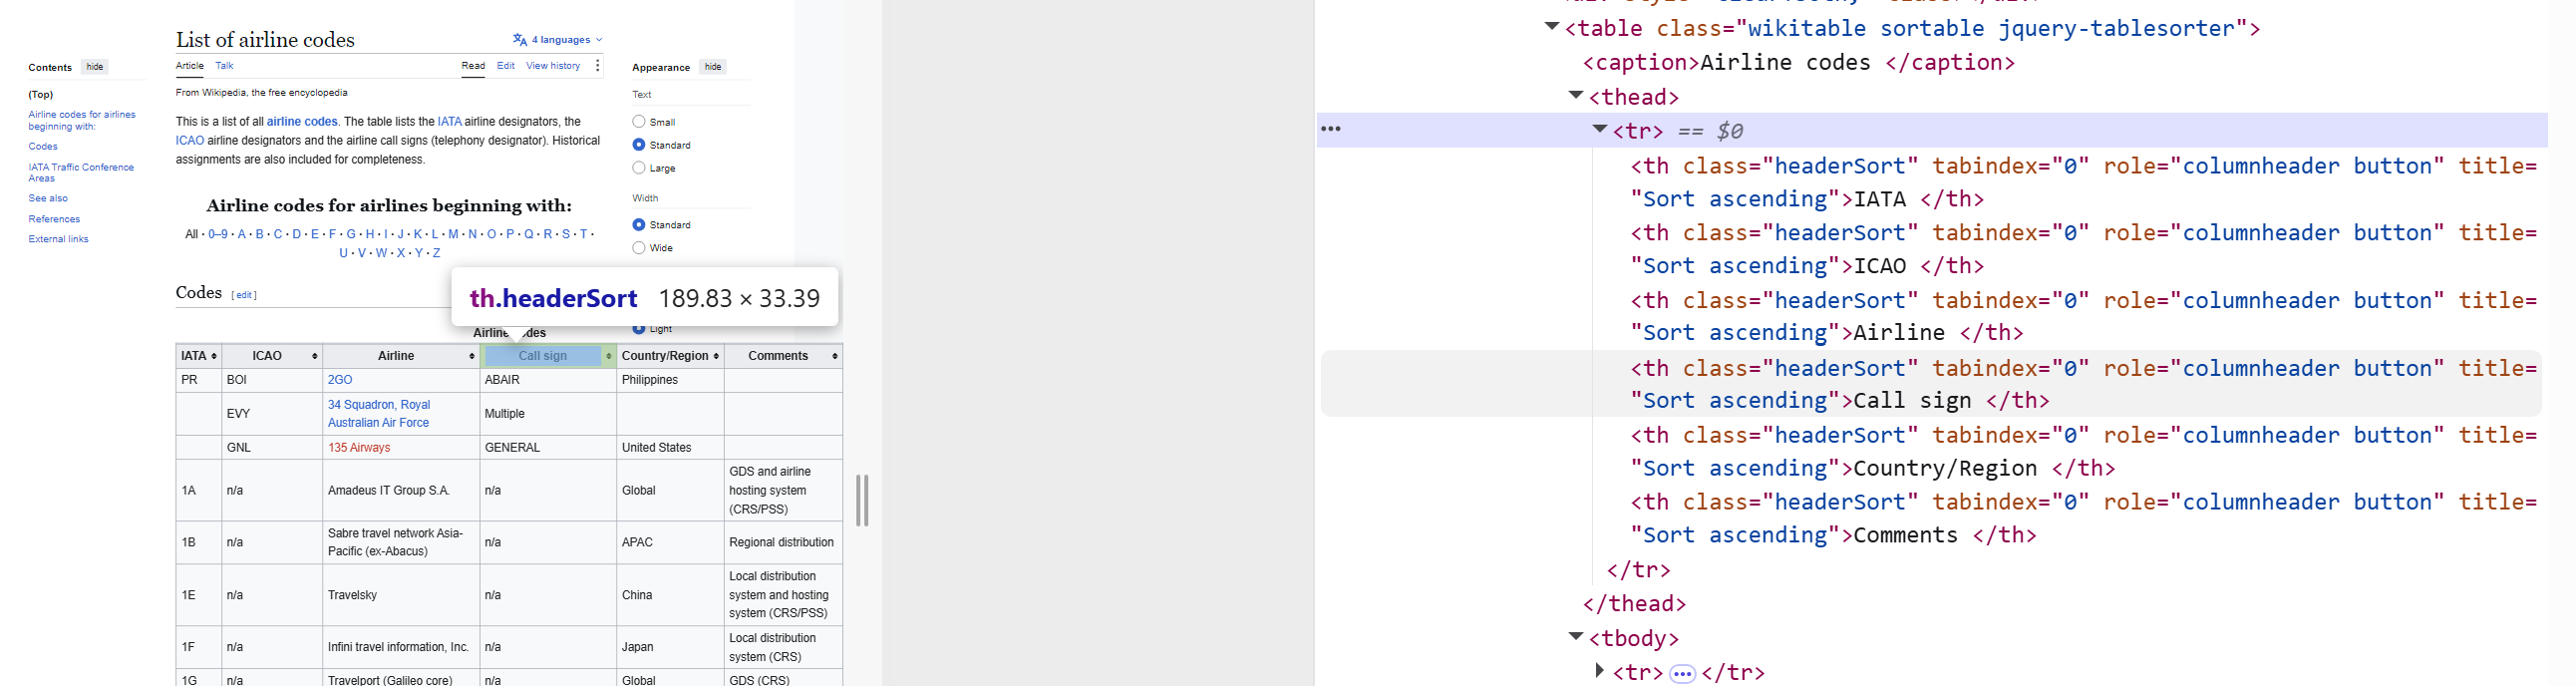
This is the structure of the table-rows:
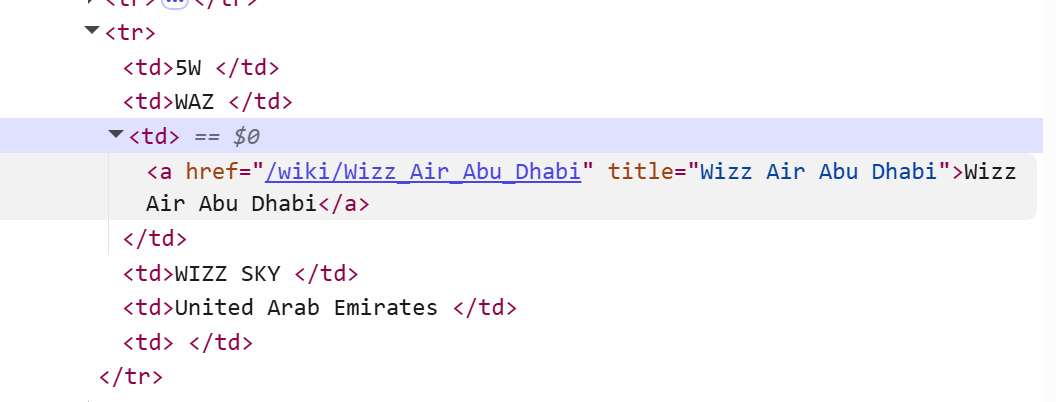

When reading cells from a row we use `find_all(['td','th'], recursive=False)`. Without `recursive=False`, BeautifulSoup also counts cells from any nested tables, which corrupts the row shape.

In [6]:
COLS = ["iata", "icao", "airline", "callsign", "country", "comments"]
recs = []
for tr in rows[1:]:
    cells = [c.get_text(strip=True) for c in tr.find_all(["td", "th"], recursive=False)]
    if len(cells) >= 5:
        recs.append((cells + [""])[:6])  # pad the few 5-cell rows

df = pd.DataFrame(recs, columns=COLS)
print("raw rows parsed:", len(df))
df.head(6)

raw rows parsed: 6353


,iata,icao,airline,callsign,country,comments
0,PR,BOI,2GO,ABAIR,Philippines,
1,,EVY,"34 Squadron, Royal Australian Air Force",Multiple,,
2,,GNL,135 Airways,GENERAL,United States,
3,1A,n/a,Amadeus IT Group S.A.,n/a,Global,GDS and airline hosting system (CRS/PSS)
4,1B,n/a,Sabre travel network Asia-Pacific (ex-Abacus),n/a,APAC,Regional distribution
5,1E,n/a,Travelsky,n/a,China,Local distribution system and hosting system (...


## Cleaning
Not every row is a usable airline:
- Some `ICAO` values are `n/a` (e.g. Amadeus, Sabre — these are GDS/booking systems, not airlines). We only want a real 3-letter alphabetic ICAO code (that's what an OpenSky callsign prefix looks like).
- Some ICAO codes appear **more than once** (code re-used by defunct + current airlines), de-duplication is needed.

In [7]:
valid = df[df["icao"].str.fullmatch(r"[A-Za-z]{3}")].copy()
print("rows with a valid 3-letter ICAO:", len(valid))
print("unique ICAO codes:", valid["icao"].nunique())
print("duplicate ICAO codes:", int(valid["icao"].duplicated().sum()))

# Lookup table: one row per ICAO (keep first occurrence)
lookup = valid.drop_duplicates(subset="icao", keep="first")[["icao", "airline", "country"]]
lookup = lookup.set_index("icao")
print("\nlookup size:", len(lookup))
for ic in ["DLH", "RYR", "EZY", "AUA", "BAW"]:
    print(ic, "->", lookup.loc[ic].to_dict() if ic in lookup.index else "NOT FOUND")

rows with a valid 3-letter ICAO: 6230
unique ICAO codes: 5890
duplicate ICAO codes: 340

lookup size: 5890
DLH -> {'airline': 'Deutsche Luft Hansa', 'country': 'Germany'}
RYR -> {'airline': 'Ryanair', 'country': 'Ireland'}
EZY -> {'airline': 'easyJet UK', 'country': 'United Kingdom'}
AUA -> {'airline': 'Austrian Airlines', 'country': 'Austria'}
BAW -> {'airline': 'British Airways', 'country': 'United Kingdom'}


## Validation with API-Data
The real test of this source: does it actually cover the commercial flights we see live? We pull a live OpenSky snapshot, take each airborne flight's callsign prefix, and check what fraction matches our scraped lookup.

In [8]:
OPENSKY_URL = "https://opensky-network.org/api/states/all"
EUROPE_BBOX = {"lamin": 34.0, "lomin": -25.0, "lamax": 72.0, "lomax": 50.0}
OS_COLS = [
    "icao24", "callsign", "origin_country", "time_position", "last_contact",
    "longitude", "latitude", "baro_altitude", "on_ground", "velocity",
    "true_track", "vertical_rate", "sensors", "geo_altitude", "squawk",
    "spi", "position_source",
]
snap = requests.get(OPENSKY_URL, params=EUROPE_BBOX, timeout=60).json()
live = pd.DataFrame(snap["states"], columns=OS_COLS)
live["callsign"] = live["callsign"].str.strip()
live = live[(~live["on_ground"]) & (live["callsign"] != "")].copy()
live["prefix"] = live["callsign"].str[:3]
live["matched"] = live["prefix"].isin(lookup.index)

print("airborne flights w/ callsign:", len(live))
print("MATCH RATE: {:.1f}%".format(100 * live['matched'].mean()))
print("\ntop unmatched prefixes (should be private/GA, i.e. correctly excluded):")
print(live[~live['matched']]['prefix'].value_counts().head(10))

airborne flights w/ callsign: 2943
MATCH RATE: 93.7%

top unmatched prefixes (should be private/GA, i.e. correctly excluded):
prefix
CHX    10
MGH     6
MBU     6
KMM     5
ECO     4
DMY     3
SEX     3
HLJ     3
ZXP     2
OMX     2
Name: count, dtype: int64
